In [1]:
# In[1]:

import os
import pegasus as pg
import ddqc
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import logging

# In[2]:

# Configuración de logging
logging.basicConfig(level=logging.INFO,
                   format='%(asctime)s - %(levelname)s - %(message)s')

# In[3]:

def plot_qc_metrics(df_qc, output_path):
    """
    Genera visualizaciones mejoradas para métricas de QC de células NK.
    
    Parameters:
    -----------
    df_qc : pandas.DataFrame
        DataFrame con métricas de QC
    output_path : str
        Ruta para guardar la figura
    """
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    
    # Distribución de conteos totales
    sns.histplot(data=df_qc, x='n_counts', ax=axs[0, 0])
    axs[0, 0].set_title('Distribución de Conteos Totales')
    axs[0, 0].axvline(np.median(df_qc['n_counts']), color='r', linestyle='--', 
                      label=f"Mediana: {np.median(df_qc['n_counts']):.0f}")
    axs[0, 0].legend()
    
    # Distribución de genes
    sns.histplot(data=df_qc, x='n_genes', ax=axs[0, 1])
    axs[0, 1].set_title('Genes por Célula NK')
    axs[0, 1].axvline(100, color='r', linestyle='--', 
                      label='Umbral mínimo: 100')
    axs[0, 1].legend()
    
    # Distribución mitocondrial
    sns.histplot(data=df_qc, x='percent_mito', ax=axs[1, 0])
    axs[1, 0].set_title('Porcentaje de Lecturas Mitocondriales')
    axs[1, 0].axvline(20, color='r', linestyle='--', 
                      label='Umbral máximo: 20%')
    axs[1, 0].legend()
    
    # Distribución ribosomal
    sns.histplot(data=df_qc, x='percent_ribo', ax=axs[1, 1])
    axs[1, 1].set_title('Porcentaje de Lecturas Ribosomales')
    axs[1, 1].legend()
    
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()

# In[4]:

def validate_nk_data(data):
    """
    Valida la presencia de marcadores NK en los datos
    """
    nk_markers = ['NCAM1', 'FCGR3A', 'KLRB1', 'NKG7', 'GNLY', 'PRF1']
    found_markers = [marker for marker in nk_markers if marker in data.var_names]
    logging.info(f"Marcadores NK encontrados: {len(found_markers)}/{len(nk_markers)}")
    return len(found_markers) > 0

# In[5]:

def process_quality_control(input_directory, qc_output_directory, filtered_output_directory):
    """
    Ejecuta control de calidad específico para células NK
    """
    # Crear directorios de salida
    os.makedirs(qc_output_directory, exist_ok=True)
    os.makedirs(filtered_output_directory, exist_ok=True)

    for filename in os.listdir(input_directory):
        if filename.endswith(".h5ad"):
            logging.info(f"Procesando {filename}...")
            filepath = os.path.join(input_directory, filename)
            
            try:
                # Cargar datos
                data = pg.read_input(filepath, genome='hg19')
                
                # Verificar conteos crudos
                if not np.issubdtype(data.X.dtype, np.integer):
                    logging.warning(f"{filename} no contiene conteos crudos en .X")
                else:
                    logging.info(f"{filename} contiene conteos crudos en .X")
                
                # Validar datos NK
                if not validate_nk_data(data):
                    logging.warning("No se encontraron suficientes marcadores NK")
                
                # Ejecutar DDQC con parámetros específicos para NK
                df_qc = ddqc.ddqc_metrics(
                    data,
                    res=1.5,                    # Mayor resolución para subpoblaciones NK
                    clustering_method="leiden",  # Método más robusto
                    n_components=30,            # Ajustado para NK
                    k=15,                       # Menor k para mejor resolución local
                    method="mad",
                    threshold=2.5,              # Más permisivo
                    n_genes_lower_bound=100,    # Umbral específico NK
                    #percent_mito_upper_bound=20,# Ajustado para alto metabolismo NK
                    basic_n_counts=50,          # QC inicial permisivo
                    basic_n_genes=50,
                    #basic_percent_mito=90,
                    return_df_qc=True,
                    display_plots=True
                )
                
                # Guardar métricas
                qc_output_path = os.path.join(qc_output_directory, f"qc_metrics_{filename}.csv")
                df_qc.to_csv(qc_output_path, index=False)
                logging.info(f"Métricas de QC guardadas en: {qc_output_path}")
                
                # Generar visualizaciones
                qc_plot_path = os.path.join(qc_output_directory, f"qc_metrics_{filename}.png")
                plot_qc_metrics(df_qc, qc_plot_path)
                logging.info(f"Visualizaciones guardadas en: {qc_plot_path}")
                
                # Filtrar datos
                pg.filter_data(data)
                
                # Verificar datos filtrados
                if not np.issubdtype(data.X.dtype, np.integer):
                    logging.warning(f"Los datos filtrados no mantienen conteos crudos")
                
                # Guardar datos filtrados
                filtered_output_path = os.path.join(filtered_output_directory, f"filtered_{filename}")
                pg.write_output(data, filtered_output_path)
                logging.info(f"Datos filtrados guardados en: {filtered_output_path}")
                
            except Exception as e:
                logging.error(f"Error procesando {filename}: {str(e)}")
                continue

2025-01-20 08:42:00,987 - INFO - Procesando NK cells_data.h5ad...


2025-01-20 08:43:56,078 - pegasusio.readwrite - INFO - h5ad file '/app/project/test_data/pipeline_articulo/1.5cell_group_filtered/NK cells_data.h5ad' is loaded.


2025-01-20 08:43:56,078 - INFO - h5ad file '/app/project/test_data/pipeline_articulo/1.5cell_group_filtered/NK cells_data.h5ad' is loaded.


2025-01-20 08:43:56,082 - pegasusio.readwrite - INFO - Function 'read_input' finished in 115.09s.


2025-01-20 08:43:56,082 - INFO - Function 'read_input' finished in 115.09s.
2025-01-20 08:43:56,084 - INFO - NK cells_data.h5ad contiene conteos crudos en .X
2025-01-20 08:43:56,085 - INFO - Marcadores NK encontrados: 6/6
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/ddqc/utils.py:16: FutureWarning: Possible nested set at position 8
  lambda x: re.match(ribo_prefix, x, flags=re.IGNORECASE) is not None
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/ddqc/utils.py:16: FutureWarning: Possible nested set at position 25
  lambda x: re.match(ribo_prefix, x, flags=re.IGNORECASE) is not None


...

2025-01-20 08:44:00,742 - INFO - After filtration, 365362 out of 365362 cell barcodes are kept in UnimodalData object hg19-rna.


2025-01-20 08:44:00,744 - pegasus.tools.preprocessing - INFO - Function 'filter_data' finished in 0.24s.
2025-01-20 08:44:05,095 - pegasusio.qc_utils - INFO - After filtration, 365362 out of 365362 cell barcodes are kept in UnimodalData object hg19-rna.


2025-01-20 08:44:05,095 - INFO - After filtration, 365362 out of 365362 cell barcodes are kept in UnimodalData object hg19-rna.


2025-01-20 08:44:05,097 - pegasus.tools.preprocessing - INFO - Function 'filter_data' finished in 0.21s.
2025-01-20 08:44:08,219 - pegasus.tools.preprocessing - INFO - After filtration, 27629/27629 genes are kept. Among 27629 genes, 17087 genes are robust.
2025-01-20 08:44:08,221 - pegasus.tools.preprocessing - INFO - Function 'identify_robust_genes' finished in 3.12s.
2025-01-20 08:44:19,413 - pegasus.tools.preprocessing - INFO - Function 'log_norm' finished in 11.19s.
2025-01-20 08:44:21,780 - pegasus.tools.hvf_selection - INFO - Function 'estimate_feature_statistics' finished in 2.37s.
2025-01-20 08:44:21,827 - pegasus.tools.hvf_selection - INFO - 2000 highly variable features have been selected.
2025-01-20 08:44:21,828 - pegasus.tools.hvf_selection - INFO - Function 'highly_variable_features' finished in 2.41s.
2025-01-20 08:45:04,921 - pegasus.tools.preprocessing - INFO - Function 'pca' finished in 43.09s.
2025-01-20 08:46:29,656 - pegasus.tools.nearest_neighbors - INFO - Function

/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/ddqc/plotting.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  my_order = df_copy.groupby(by=by)[column].median().sort_values(ascending=False).index
2025-01-20 09:07:50,739 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 09:07:51,332 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


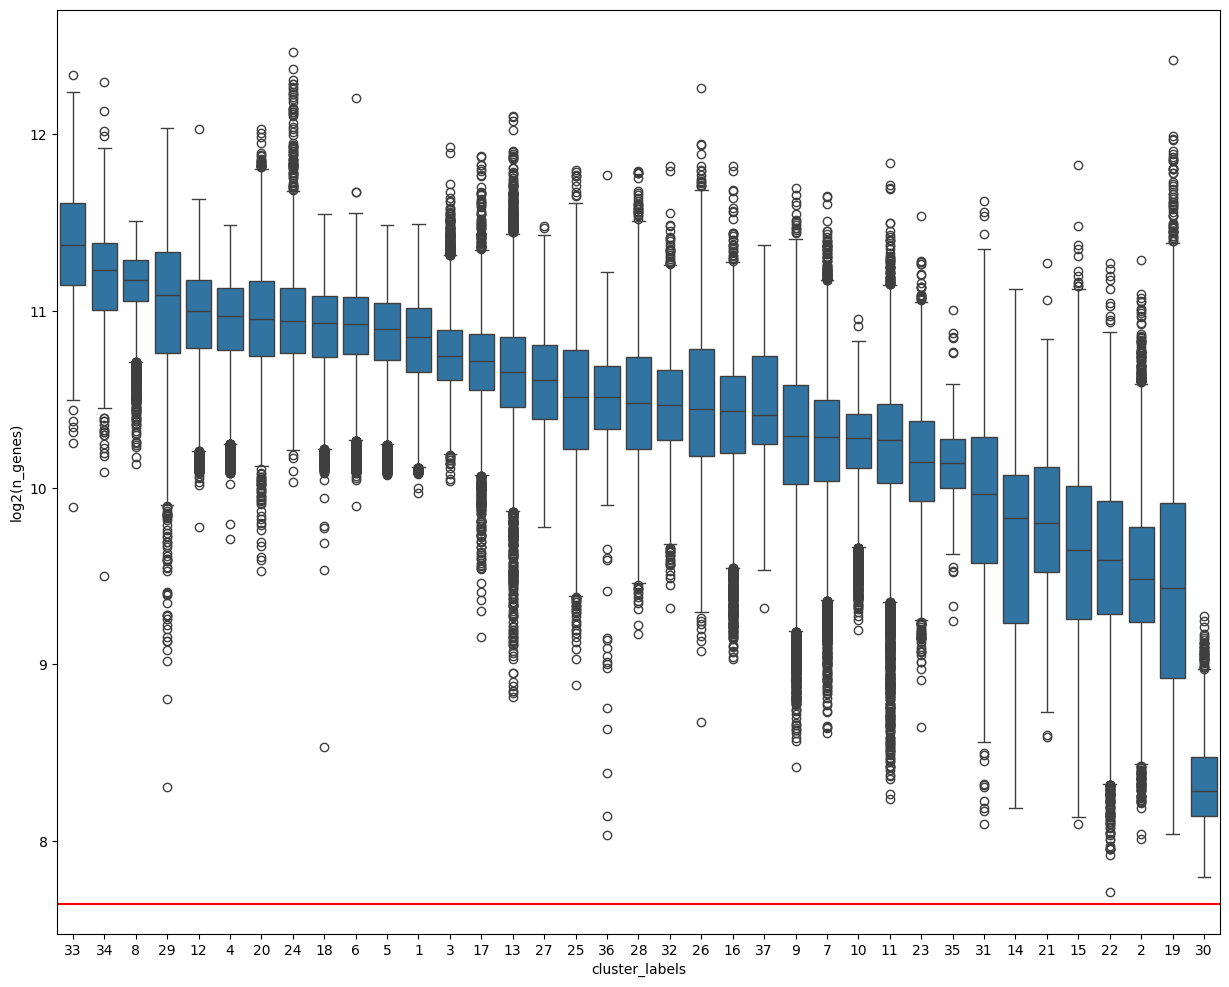

/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/ddqc/plotting.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  my_order = df_copy.groupby(by=by)[column].median().sort_values(ascending=False).index
2025-01-20 09:07:52,280 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 09:07:52,867 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


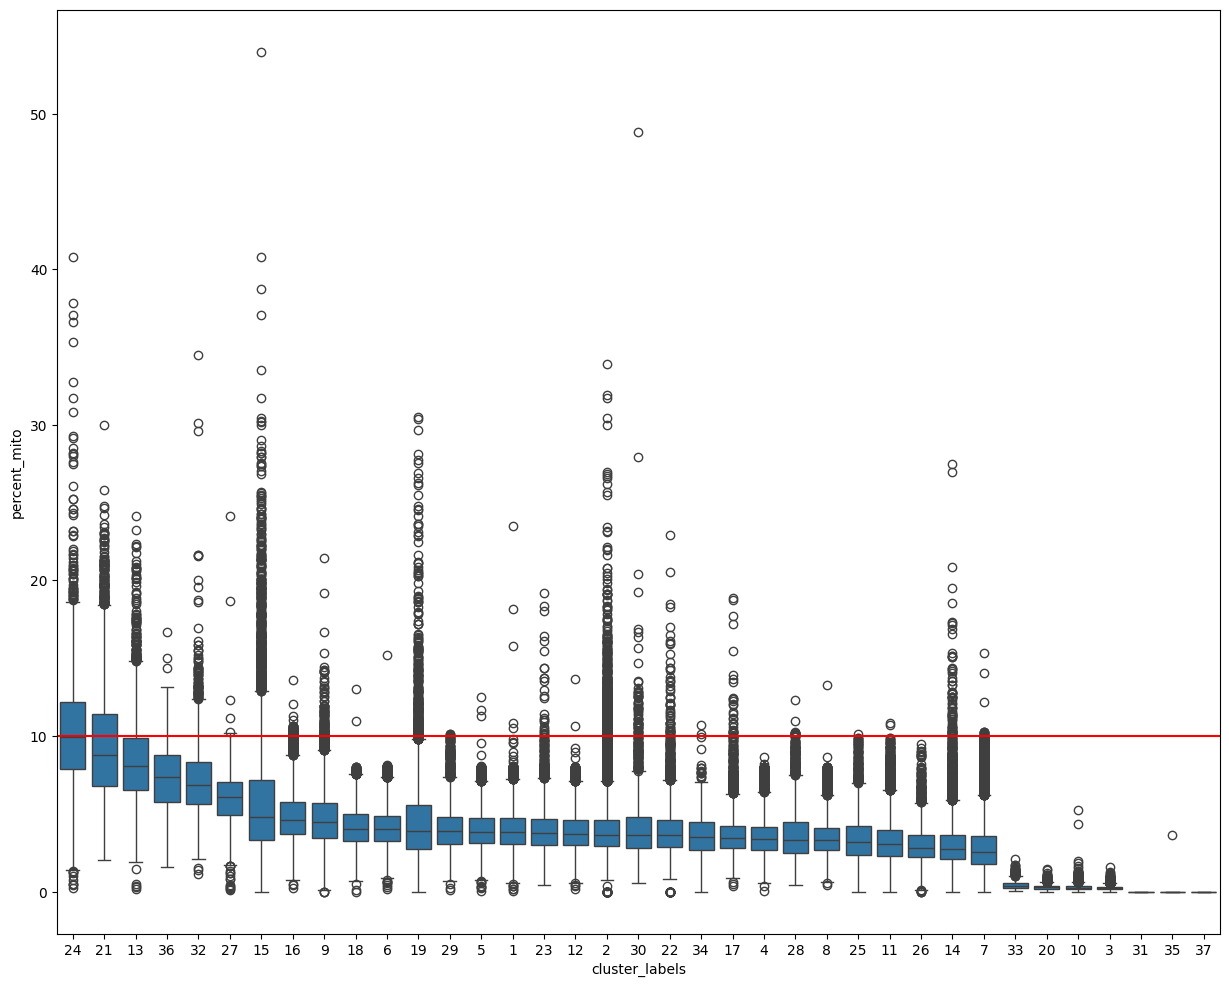

/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/ddqc/filtering.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  filtering_stats = pd.concat([filtering_stats, pd.DataFrame.from_records(cl_filtering_stats)])


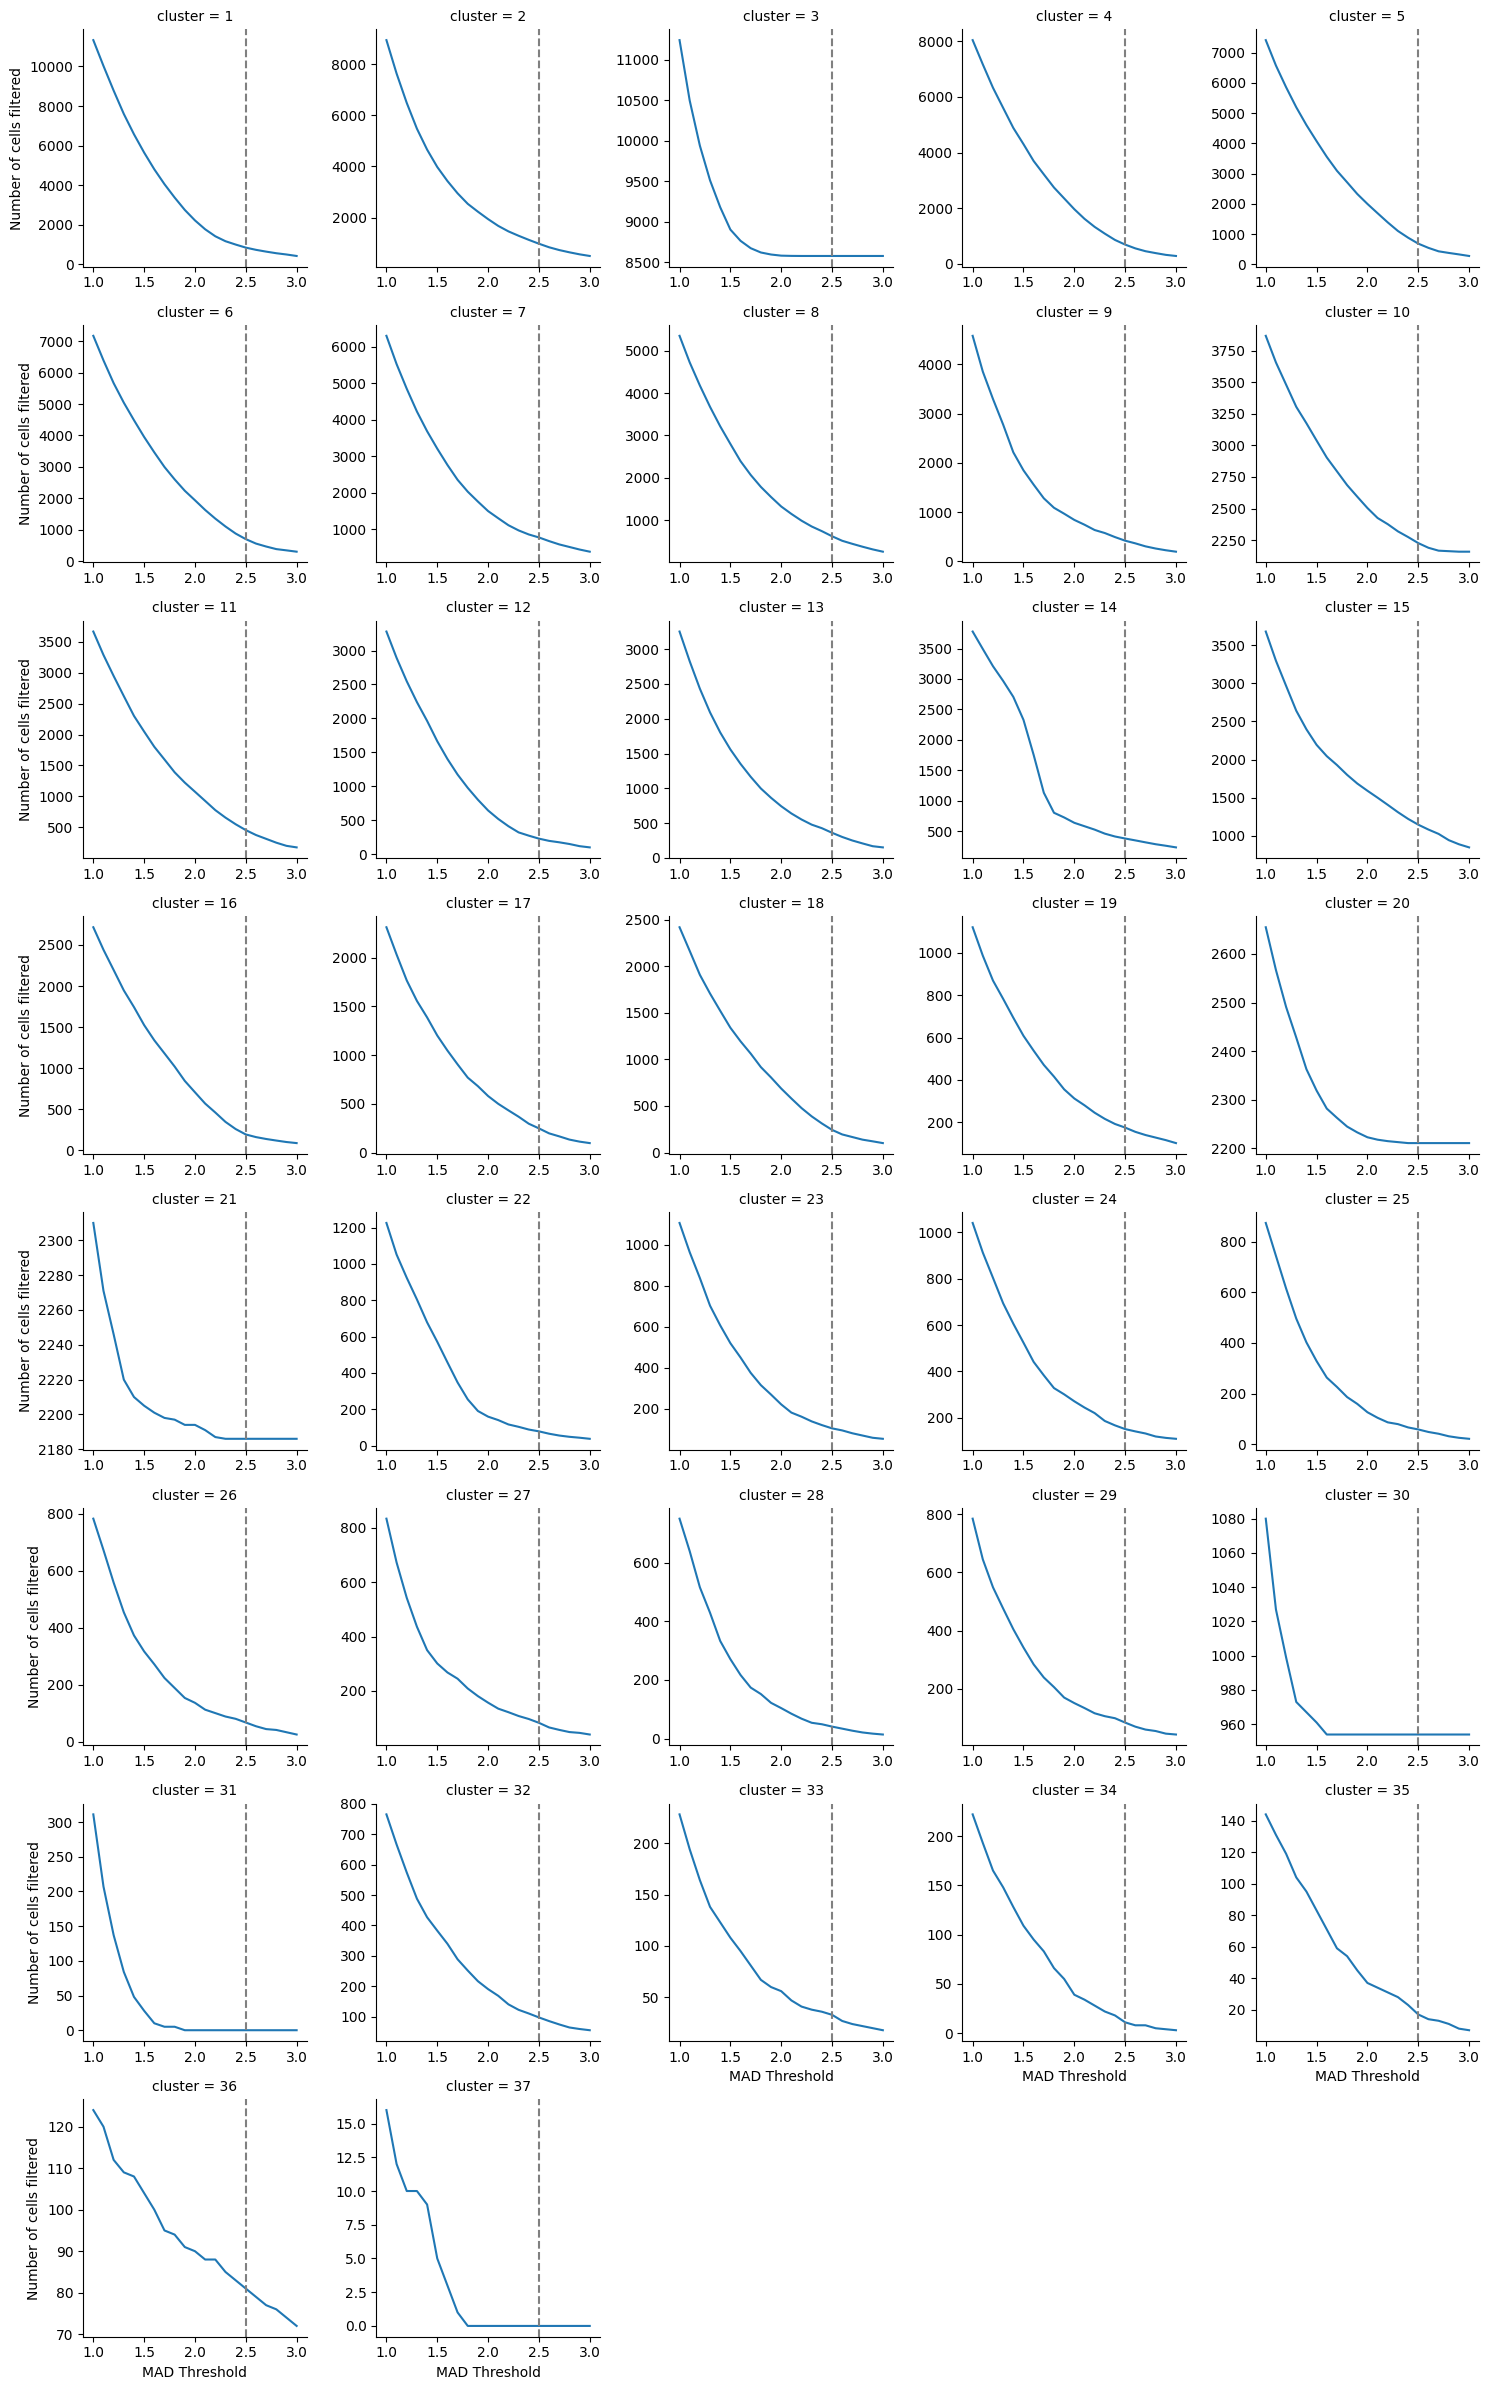

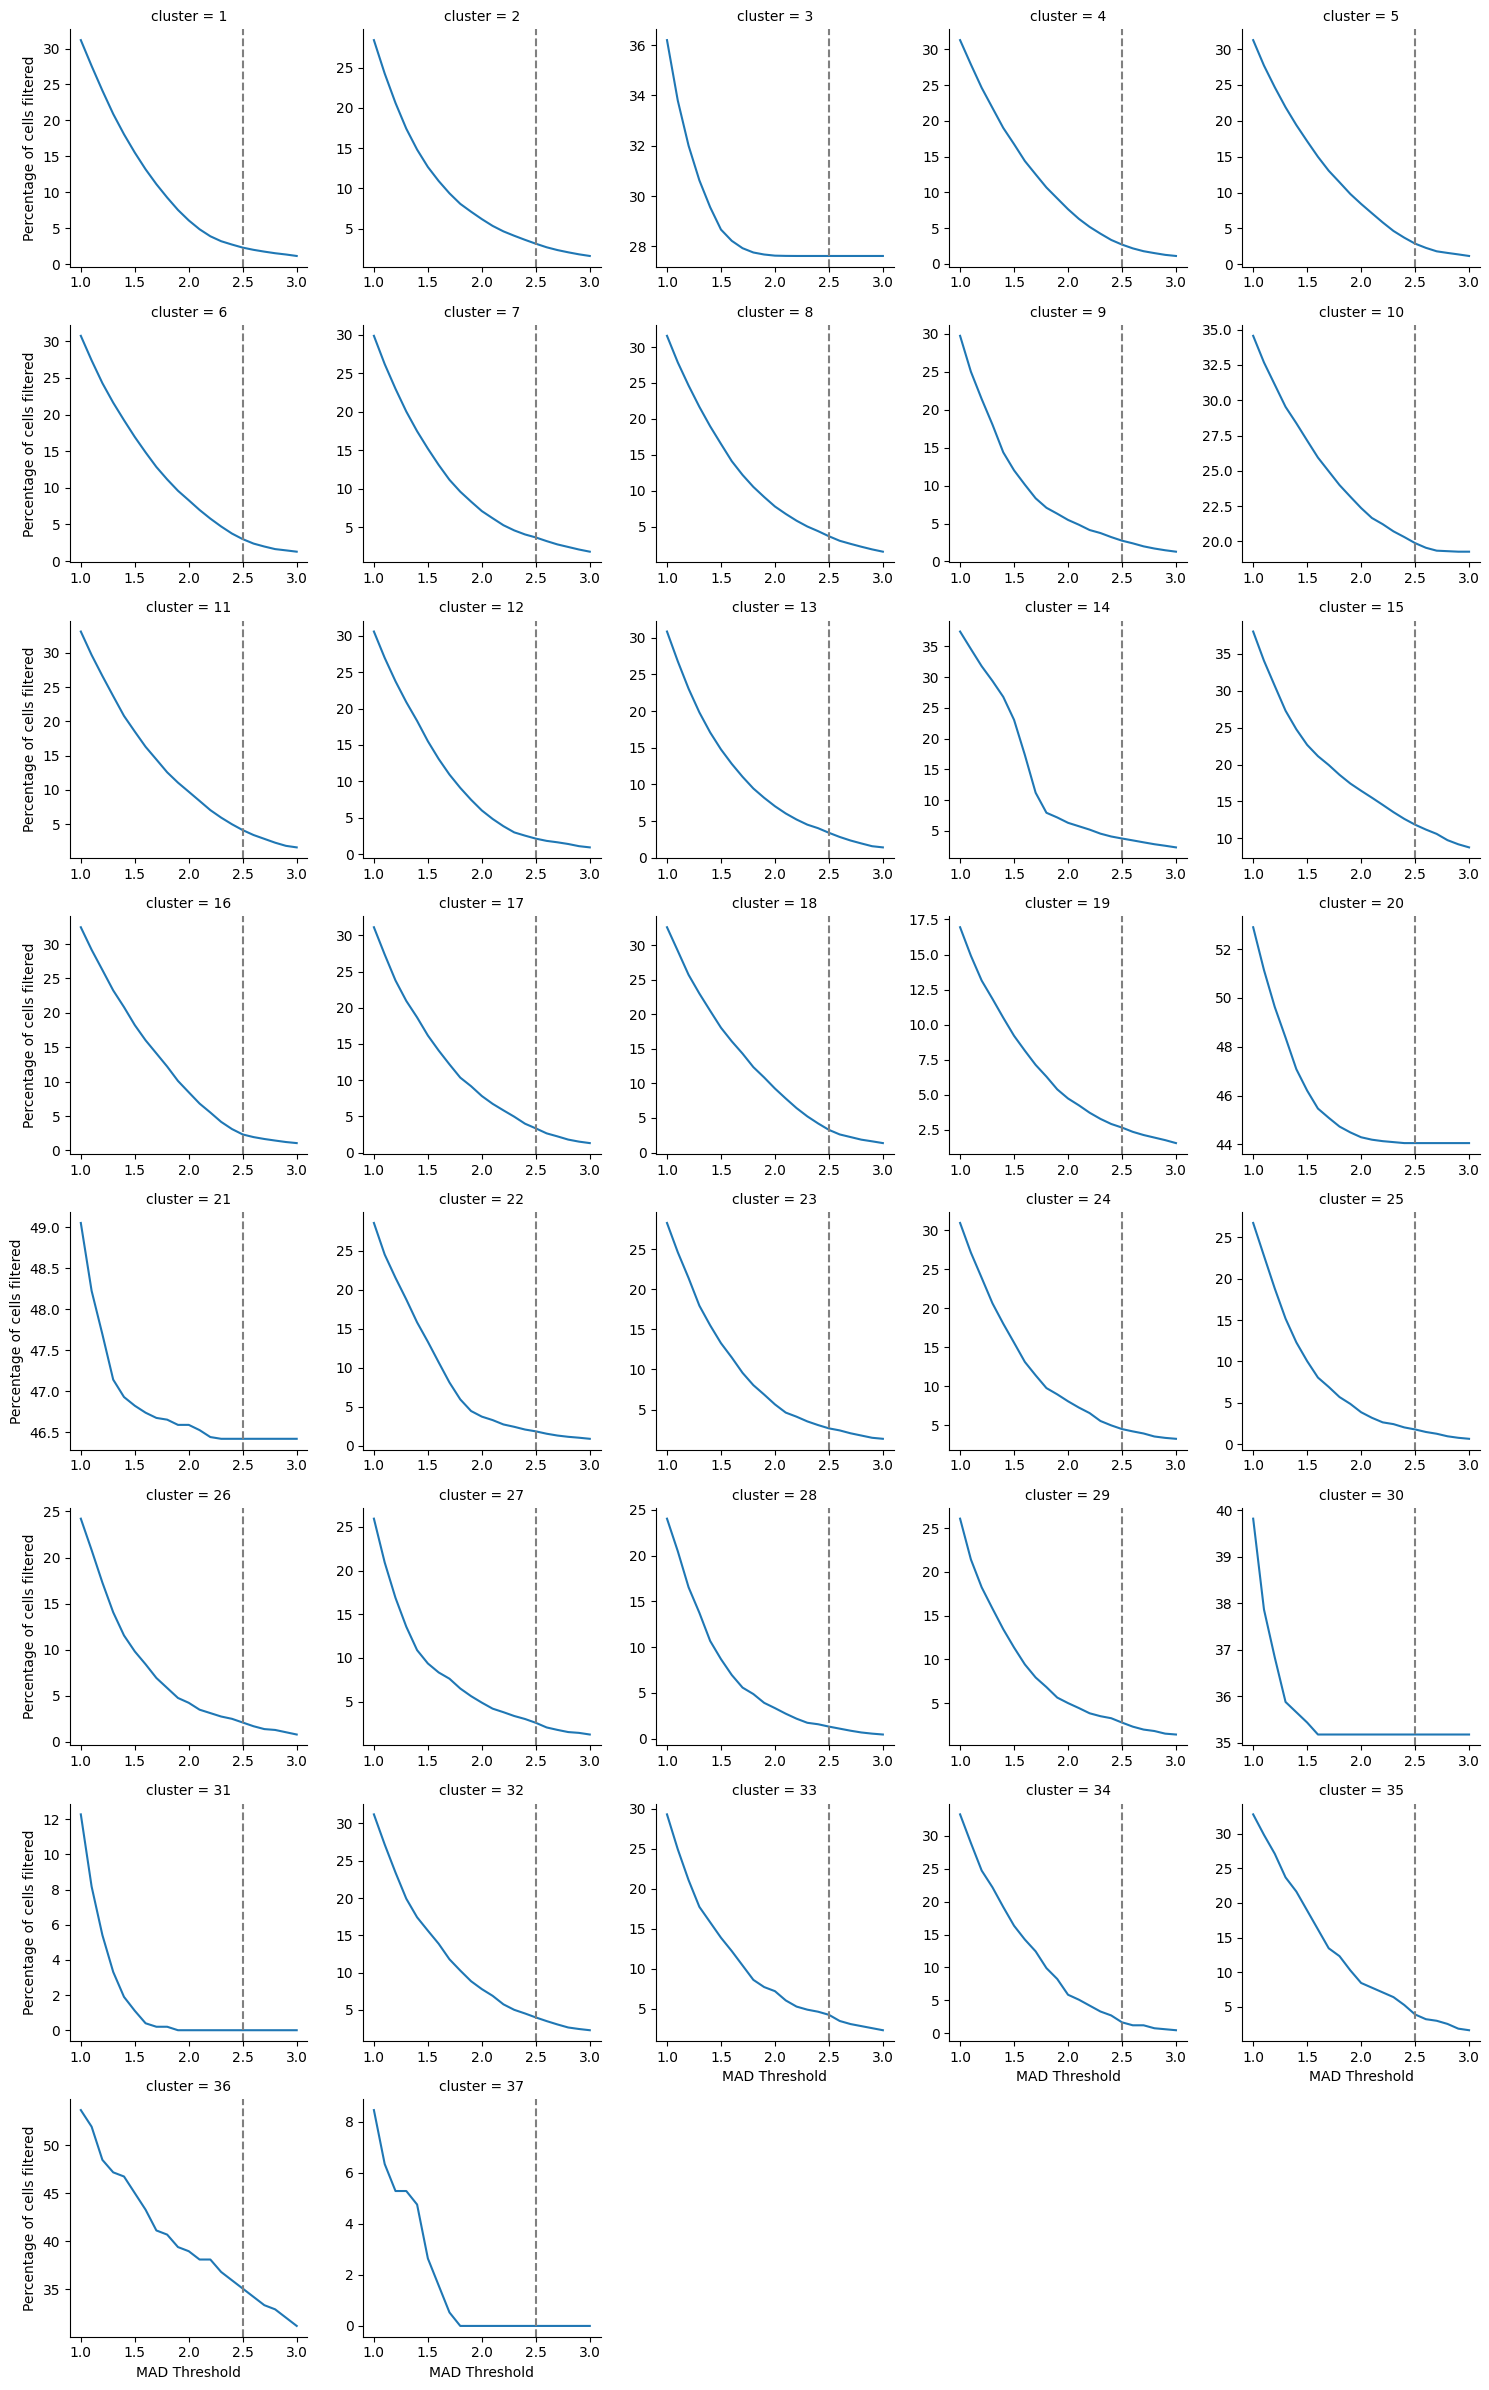

2025-01-20 09:08:47,698 - INFO - Métricas de QC guardadas en: /app/project/test_data/pipeline_articulo/2.quality_metrics/qc_metrics_NK cells_data.h5ad.csv
/tmp/ipykernel_14017/2132193399.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1, 1].legend()
/tmp/ipykernel_14017/2132193399.py:58: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_14017/2132193399.py:59: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(output_path)
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


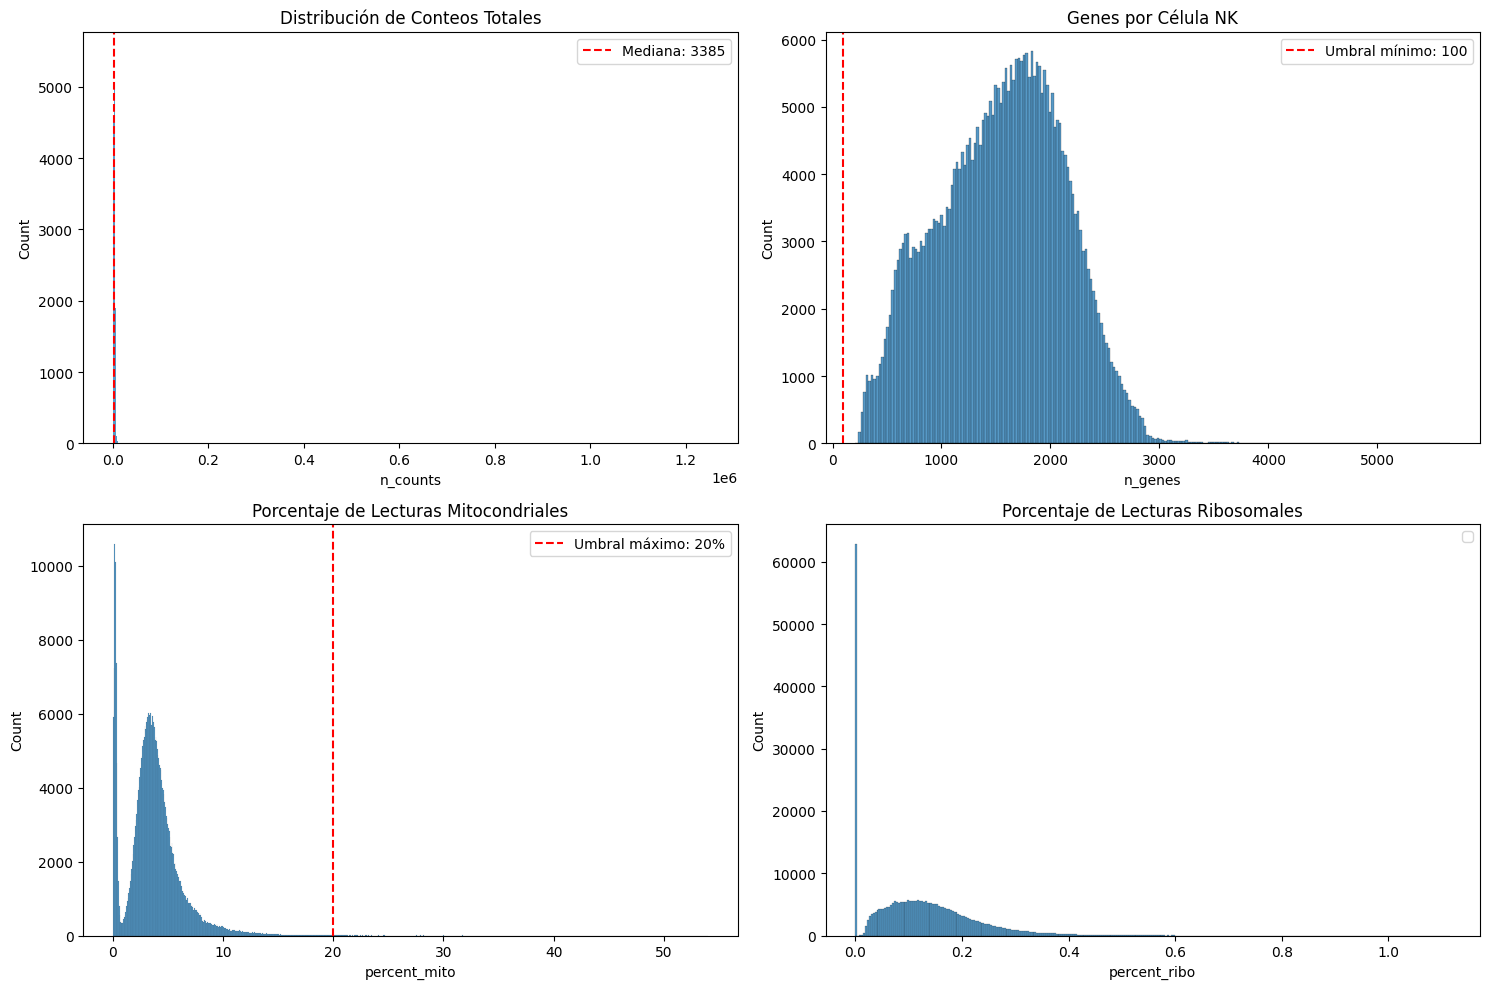

2025-01-20 09:09:45,551 - INFO - Visualizaciones guardadas en: /app/project/test_data/pipeline_articulo/2.quality_metrics/qc_metrics_NK cells_data.h5ad.png


2025-01-20 09:09:48,155 - pegasusio.qc_utils - INFO - After filtration, 339154 out of 365362 cell barcodes are kept in UnimodalData object hg19-rna.


2025-01-20 09:09:48,155 - INFO - After filtration, 339154 out of 365362 cell barcodes are kept in UnimodalData object hg19-rna.


2025-01-20 09:09:48,158 - pegasus.tools.preprocessing - INFO - Function 'filter_data' finished in 2.61s.
2025-01-20 09:11:42,408 - pegasusio.readwrite - INFO - h5ad file '/app/project/test_data/pipeline_articulo/2.quality_control/filtered_NK cells_data.h5ad' is written.


2025-01-20 09:11:42,408 - INFO - h5ad file '/app/project/test_data/pipeline_articulo/2.quality_control/filtered_NK cells_data.h5ad' is written.


2025-01-20 09:11:42,412 - pegasusio.readwrite - INFO - Function 'write_output' finished in 114.25s.


2025-01-20 09:11:42,412 - INFO - Function 'write_output' finished in 114.25s.
2025-01-20 09:11:42,414 - INFO - Datos filtrados guardados en: /app/project/test_data/pipeline_articulo/2.quality_control/filtered_NK cells_data.h5ad


In [2]:

# Definir directorios
input_directory = "/app/project/test_data/pipeline_articulo/1.5cell_group_filtered/"
qc_output_directory = "/app/project/test_data/pipeline_articulo/2.quality_metrics"
filtered_output_directory = "/app/project/test_data/pipeline_articulo/2.quality_control"

# In[7]:

# Ejecutar pipeline de QC
process_quality_control(input_directory, qc_output_directory, filtered_output_directory)